# How to use TA-Lib to generate Alpha Factors

## Imports & Settings

In [14]:
import warnings
warnings.filterwarnings('ignore')

In [15]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from talib import RSI, BBANDS, MACD

In [16]:
sns.set_style('whitegrid')
idx = pd.IndexSlice

## Get Data

The `assets.h5` store can be generated using the the notebook [create_datasets](../../data/create_datasets.ipynb) in the [data](../../data) directory in the root directory of this repo for instruction to download the following dataset.

Set data store location:

In [24]:
import pandas as pd

# Load the HDF5 file and extract all columns except 'Adj Close' for the AAPL ticker
with pd.HDFStore('data_store.h5') as store:
    prices = store['prices']

# Ensure the 'Date' level is datetime
prices.index = prices.index.set_levels(
    pd.to_datetime(prices.index.levels[0]), level='Date'
)

# Extract all columns for the AAPL ticker
aapl_data = prices.xs('AAPL', level='Ticker')

# Drop the 'Adj Close' column if it exists
aapl_data = aapl_data.drop(columns=['Adj Close'], errors='ignore')

# Display the result
print(aapl_data.head())


Price           Close       High        Low       Open       Volume
Date                                                               
2020-01-02  72.620827  72.681274  71.373203  71.627077  135480400.0
2020-01-03  71.914803  72.676431  71.689942  71.847102  146322800.0
2020-01-06  72.487862  72.526549  70.783263  71.034724  118387200.0
2020-01-07  72.146927  72.753808  71.926900  72.497514  108872000.0
2020-01-08  73.307518  73.609752  71.849540  71.849540  132079200.0


We load the AAPL stock price for the 2007-10 using `pd.IndexSlice` to perform a slice operation on the `pd.MultiIndex`, select the adjusted close price and unpivot the column to convert the DataFrame to wide format with tickers in the columns and timestamps in the rows:

In [26]:
data = aapl_data

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   756 non-null    float64
 1   High    756 non-null    float64
 2   Low     756 non-null    float64
 3   Open    756 non-null    float64
 4   Volume  756 non-null    float64
dtypes: float64(5)
memory usage: 35.4 KB


## Compute Bollinger Bands

In [29]:
up, mid, low = BBANDS(data.Close, timeperiod=21, nbdevup=2, nbdevdn=2, matype=0)

## Compute Relative Strength Index

In [30]:
rsi = RSI(data.Close, timeperiod=14)

## Moving Average Convergence/Divergence

The MACD computes the difference between two Exponential Moving Averages (EMA), one longer- and one shorter-term.

The ta-lib MACD Indicator implementation has four inputs:
- the close price
- `fastperiod`: the short-term EMA period
- `slowperiod`: the long-term EMA period
- `signalperiod`: the period for the EMA of the MACD itself

It has three outputs:
- `macd` is the difference between the fast EMA and slow EMA.
- `macdsignal` is the EMA of the MACD value with period `signalperiod`
- `macdhist` computes the difference between `macd` and `macdsignal`

In [31]:
macd, macdsignal, macdhist = MACD(data.Close, fastperiod=12, slowperiod=26, signalperiod=9)

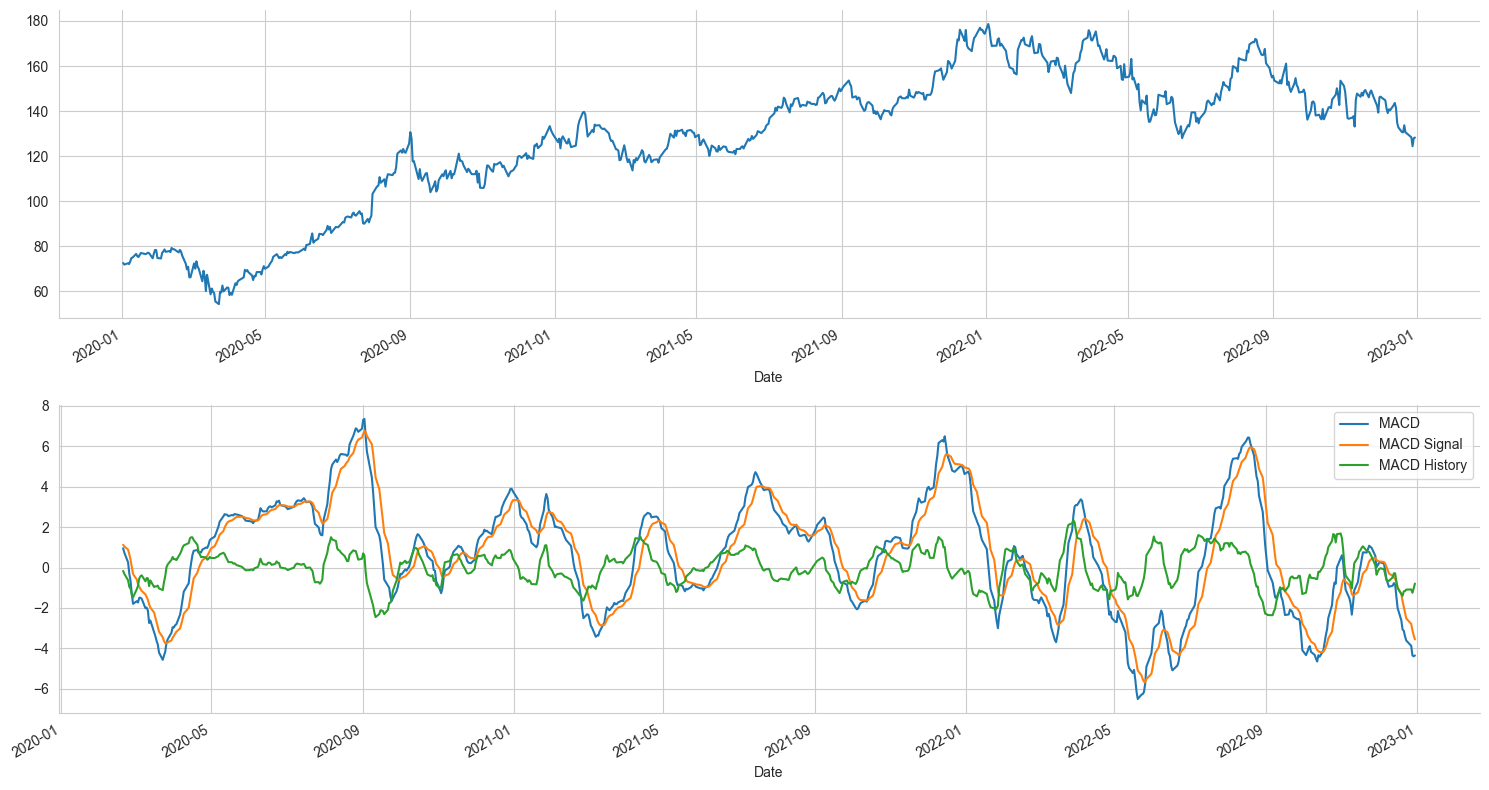

In [32]:
macd_data = pd.DataFrame({'AAPL': data.Close, 'MACD': macd, 'MACD Signal': macdsignal, 'MACD History': macdhist})

fig, axes= plt.subplots(nrows=2, figsize=(15, 8))
macd_data.AAPL.plot(ax=axes[0])
macd_data.drop('AAPL', axis=1).plot(ax=axes[1])
fig.tight_layout()
sns.despine();

## Plot Result

In [33]:
data = pd.DataFrame({'AAPL': data.Close, 'BB Up': up, 'BB Mid': mid, 'BB down': low, 'RSI': rsi, 'MACD': macd})

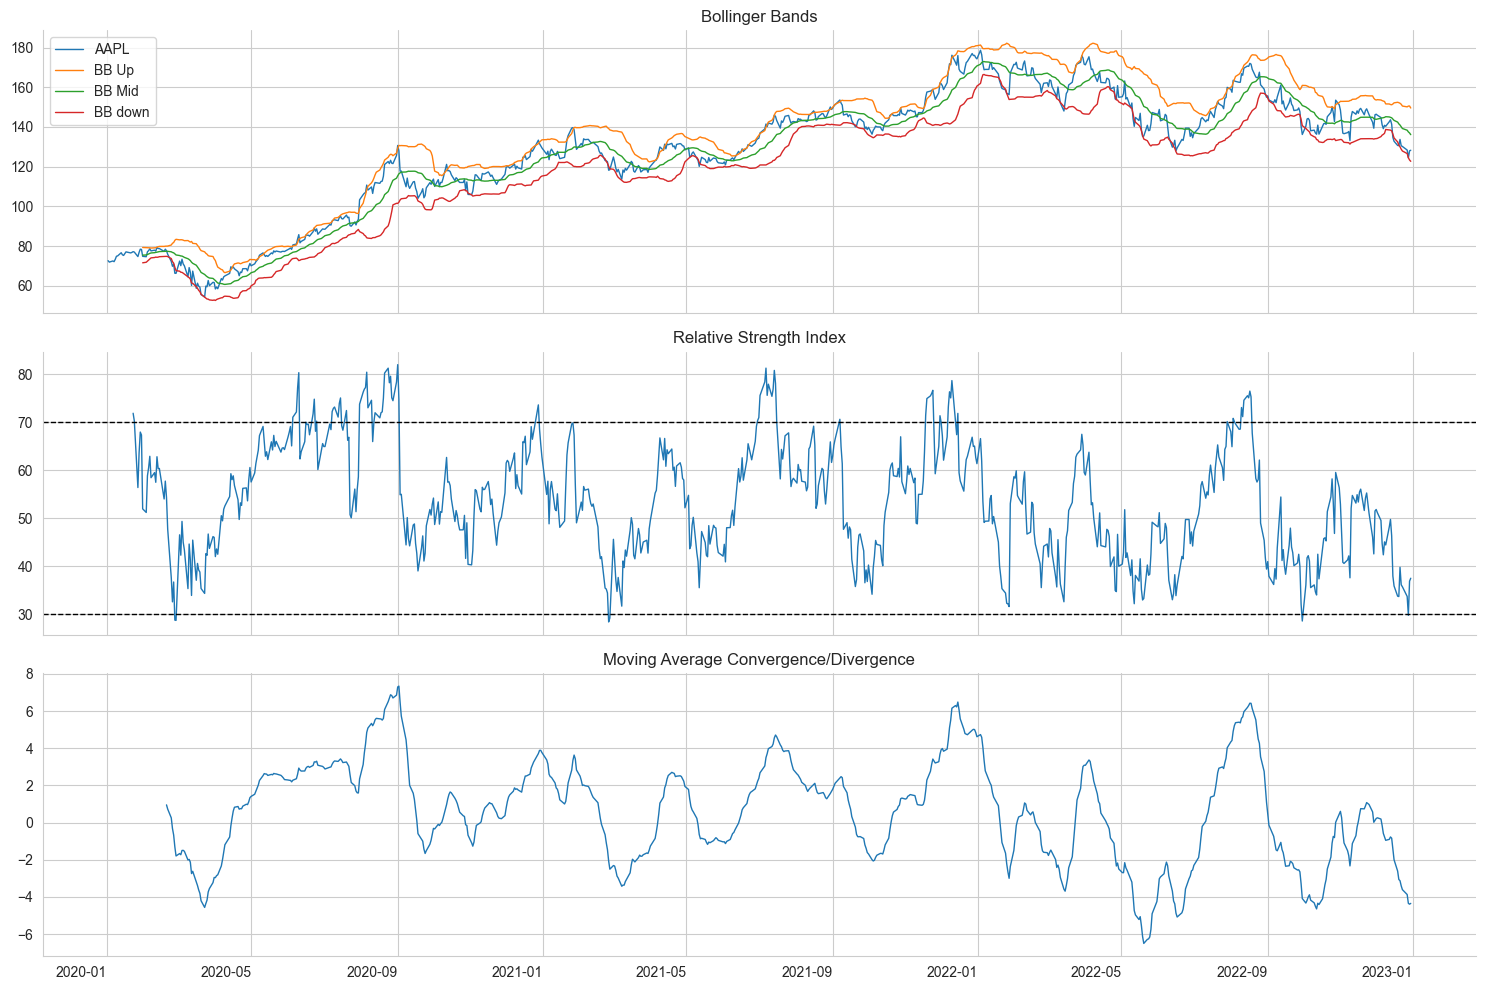

In [34]:
fig, axes= plt.subplots(nrows=3, figsize=(15, 10), sharex=True)
data.drop(['RSI', 'MACD'], axis=1).plot(ax=axes[0], lw=1, title='Bollinger Bands')
data['RSI'].plot(ax=axes[1], lw=1, title='Relative Strength Index')
axes[1].axhline(70, lw=1, ls='--', c='k')
axes[1].axhline(30, lw=1, ls='--', c='k')
data.MACD.plot(ax=axes[2], lw=1, title='Moving Average Convergence/Divergence', rot=0)
axes[2].set_xlabel('')
fig.tight_layout()
sns.despine();